In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pingouin as pg
import scikit_posthocs as sp

In [66]:
df = pd.read_csv("Output_extraction/ai_grading_final.csv")

df["prompt_type"] = pd.Categorical(df["prompt_type"], 
    categories=["very_pessimistic", "pessimistic", "neutral", "confident", "very_confident"], 
    ordered=True)

required_columns = [
    "answer_key_id",
    "true_mistakes",
    "prompt_type",
    "ai_estimated_mistakes"
]
df = df.dropna()

df["ai_error"] = df["ai_estimated_mistakes"] - df["true_mistakes"]
df["Absolute_error"] = abs(df["ai_estimated_mistakes"]-df["true_mistakes"])

df["true_mistakes"] = df["true_mistakes"].astype("category")
df["prompt_type"] = df["prompt_type"].astype("category")

pd.set_option("display.max_rows", None)

We use the Kruskal–Wallis test because the groups are tested on independent data. Within each group, the answer sheets are not necessarily unique, but each AI assessment is independent because the model has no memory or knowledge of earlier or later runs.

We acknowledge that, for 0 true mistakes, the AI may assess the same sheet several times, while groups such as 6 true mistakes contain more variation because different combinations of answers can be wrong. However, the AI does not know the true number of mistakes or the correct answers in advance and must evaluate every answer in each run. Therefore, repeated sheets do not automatically invalidate the test, but the unequal sheet diversity between groups should be considered a limitation.


Signed error og absolute error har afhængigt af true mistake forskellige mulige grænser for deres værdier. ved 0 fejl, kan signed error ikke blive minus. ved absolute error er der forskel på ved true mistake 8 kan abs error maks blive 8, ved 15 kan den blive 15. 

Kruskal wallis ranker de 16 forskellige grupper som true mistakes laver og ser og disse rankseret grupper ligger langt fra hinanden. Man rangere ved at opstille alle 100*16 punkter og rangere efter lavest absolute error=0 til højest. hvis 2 punkter (dette sker meget) så tager man gennemsnittet lad os sige piunkt 370-600 alle havde absolute error, ville man give alle disse punkter samme rank som ville være (370+171+172,...,600)/(600-370). derefter samles punkterne i deres true_error grupper  og der måles om ranks ligger meget langt fra hinanden i de forskellige grupper, se nedenunder.

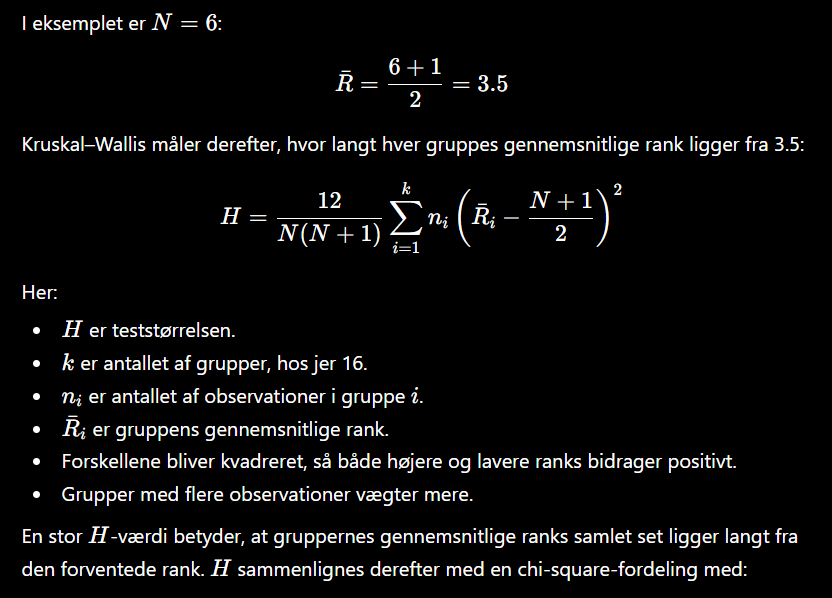

Start med et overlook over True_mistake grupperne sammenlignet

In [67]:
display(
    df.groupby("true_mistakes")[
        ["ai_error", "Absolute_error"]
    ].agg(["count", "mean", "std", "nunique"])
)

ai_error                             Absolute_error            \
                 count      mean       std nunique          count      mean   
true_mistakes                                                                 
0                  250  0.092000  0.316126       3            250  0.092000   
2                  250  0.316000  1.041385       8            250  0.364000   
4                  249  0.180723  0.764292       8            249  0.253012   
6                  250  0.080000  0.589057       7            250  0.216000   
8                  249 -0.012048  0.715508       7            249  0.301205   
10                 250 -0.132000  0.696070       7            250  0.292000   
12                 250 -0.308000  0.824533       7            250  0.388000   
14                 249 -0.453815  1.073356       7            249  0.485944   

                                 
                    std nunique  
true_mistakes                    
0              0.316126       3  
2              1.025530       7  
4              0.743413       7  
6              0.553688       5  
8              0.648850       5  
10             0.645292       5  
12             0.789906       5  
14             1.059140       6

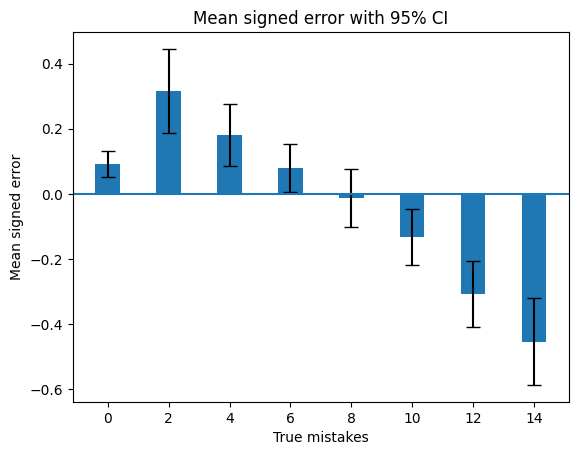

In [68]:
summary = df.groupby("true_mistakes")["ai_error"].agg(["mean", "std", "count"])

summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["count"])

plt.bar(
    summary.index,
    summary["mean"],
    yerr=summary["ci95"],
    capsize=5
)

plt.axhline(0)
plt.xlabel("True mistakes")
plt.ylabel("Mean signed error")
plt.title("Mean signed error with 95% CI")
plt.show()

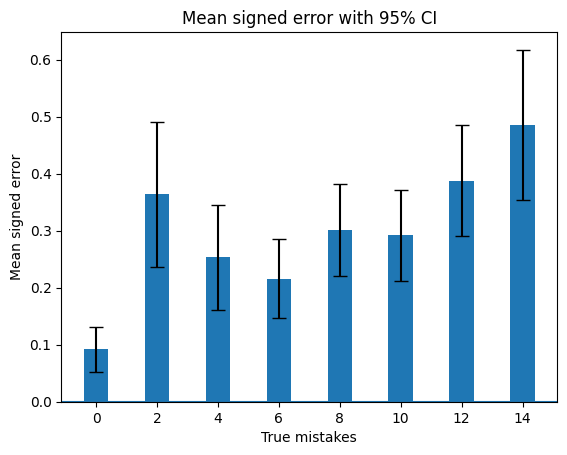

In [69]:
summary = df.groupby("true_mistakes")["Absolute_error"].agg(["mean", "std", "count"])

summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["count"])

plt.bar(
    summary.index,
    summary["mean"],
    yerr=summary["ci95"],
    capsize=5
)

plt.axhline(0)
plt.xlabel("True mistakes")
plt.ylabel("Mean signed error")
plt.title("Mean signed error with 95% CI")
plt.show()

In [70]:
# ── Kruskal-Wallis for true_mistakes ───────────────────────────────────────────

# Med ai_error (signed)
kw_signed = pg.kruskal(
    data=df,
    dv="ai_error",
    between="true_mistakes"
)
print("=== Kruskal-Wallis: ai_error (signed) ===")
print(kw_signed)

# Med Absolute_error
kw_absolute = pg.kruskal(
    data=df,
    dv="Absolute_error",
    between="true_mistakes"
)
print("\n=== Kruskal-Wallis: Absolute_error ===")
print(kw_absolute)

=== Kruskal-Wallis: ai_error (signed) ===
                Source  ddof1           H         p_unc
Kruskal  true_mistakes      7  155.159497  3.344847e-30

=== Kruskal-Wallis: Absolute_error ===
                Source  ddof1          H     p_unc
Kruskal  true_mistakes      7  37.114952  0.000004


Bruger nu dunns da denne er lavet til at følge op efter kruskal

In [71]:
def dunn_test(data, outcome):
    # Fjern eventuelle manglende værdier
    clean = data[["true_mistakes", outcome]].dropna()

    # Dunn-test med Holm-korrektion
    p_values = sp.posthoc_dunn(
        clean,
        val_col=outcome,
        group_col="true_mistakes",
        p_adjust="holm"
    )

    # Behold kun hver sammenligning én gang
    mask = np.triu(np.ones(p_values.shape, dtype=bool), k=1)

    results = (
        p_values
        .where(mask)
        .rename_axis(index="A", columns="B")
        .stack()
        .reset_index(name="p_corr")
        .dropna(subset=["p_corr"])
        .reset_index(drop=True)
    )

    return results

signed error

In [72]:
posthoc_signed_true = dunn_test(df, "ai_error")

display(posthoc_signed_true)
display(posthoc_signed_true[posthoc_signed_true["p_corr"] < 0.05])

,A,B,p_corr
0,0,2,1.000000e+00
1,0,4,1.000000e+00
2,0,6,1.000000e+00
3,0,8,2.607365e-02
4,0,10,1.167494e-03
5,0,12,3.026299e-10
6,0,14,7.280431e-13
7,2,4,1.000000e+00
8,2,6,1.930577e-01
9,2,8,1.992238e-04


,A,B,p_corr
3,0,8,2.607365e-02
4,0,10,1.167494e-03
5,0,12,3.026299e-10
6,0,14,7.280431e-13
9,2,8,1.992238e-04
10,2,10,2.349597e-06
11,2,12,1.510070e-14
12,2,14,1.173451e-17
14,4,8,1.082004e-02
15,4,10,3.765317e-04


Absolute error

In [73]:
posthoc_absolute_true = dunn_test(df, "Absolute_error")

print("\n=== Dunn's post-hoc test: absolute error ===")
display(posthoc_absolute_true)
display(posthoc_absolute_true[posthoc_absolute_true["p_corr"] < 0.05])


=== Dunn's post-hoc test: absolute error ===


,A,B,p_corr
0,0,2,0.083561
1,0,4,0.357491
2,0,6,0.297195
3,0,8,0.000832
4,0,10,0.002404
5,0,12,0.000026
6,0,14,0.000041
7,2,4,1.000000
8,2,6,1.000000
9,2,8,1.000000


,A,B,p_corr
3,0,8,0.000832
4,0,10,0.002404
5,0,12,0.000026
6,0,14,0.000041


Sample size calculation med cohens effectsize

In [74]:
def add_sample_size(results, outcome):
    results = results.copy()
    alpha = 0.05 / len(results)  # 120 comparisons

    def calculate(row):
        x = df.loc[df["true_mistakes"] == row["A"], outcome]
        y = df.loc[df["true_mistakes"] == row["B"], outcome]

        d = abs(pg.compute_effsize(x, y, paired=False, eftype="cohen"))

        n = np.inf if d == 0 else np.ceil(
            pg.power_ttest(
                d=d,
                n=None,
                power=0.80,
                alpha=alpha,
                contrast="two-samples"
            )
        )

        return d, n

    results[["cohen_d", "required_n"]] = results.apply(
        calculate, axis=1, result_type="expand"
    )

    return results

In [75]:
results_signed = add_sample_size(posthoc_signed_true, "ai_error")

with pd.option_context("display.max_rows", None):
    display(
        results_signed[
            ["A", "B", "p_corr", "cohen_d", "required_n"]
        ]
    )


,A,B,p_corr,cohen_d,required_n
0,0,2,1.000000e+00,0.291079,374.0
1,0,4,1.000000e+00,0.151812,1367.0
2,0,6,1.000000e+00,0.025385,48805.0
3,0,8,2.607365e-02,0.188238,890.0
4,0,10,1.167494e-03,0.414371,186.0
5,0,12,3.026299e-10,0.640598,80.0
6,0,14,7.280431e-13,0.690432,69.0
7,2,4,1.000000e+00,0.148057,1438.0
8,2,6,1.930577e-01,0.278956,407.0
9,2,8,1.992238e-04,0.367046,236.0


In [76]:
results_absolute = add_sample_size(
    posthoc_absolute_true,
    "Absolute_error"
)

with pd.option_context("display.max_rows", None):
    display(
        results_absolute[
            ["A", "B", "p_corr", "cohen_d", "required_n"]
        ]
    )

,A,B,p_corr,cohen_d,required_n
0,0,2,0.083561,0.358446,248.0
1,0,4,0.357491,0.282068,398.0
2,0,6,0.297195,0.275045,419.0
3,0,8,0.000832,0.410168,190.0
4,0,10,0.002404,0.393621,206.0
5,0,12,0.000026,0.492007,133.0
6,0,14,0.000041,0.504464,127.0
7,2,4,1.000000,0.123880,2052.0
8,2,6,1.000000,0.179590,978.0
9,2,8,1.000000,0.073147,5881.0
